# Presenting a Fitness Studio Expansion Analysis (SOLUTION)

## Scenario

You are a decision scientist at **Apex Athletic Co.**, a boutique fitness chain. A complete
sensitivity and scenario analysis for three studio formats has already been run —
the analysis code is in the **Given analysis** section below, which runs automatically.
You have:

- A 5-year lease NPV (Net Present Value) model for three formats (Flagship, Studio, Express)
  with base-case numbers derived from BLS recreation services price data.
- A tornado diagram showing which inputs drive the Studio format's NPV most.
- Three named scenarios (Optimistic, Base, Pessimistic) across all formats.
- A break-even daily visit count for the Studio format.

The VP of Real Estate has asked for a decision brief. She is not a data scientist.
She wants to know: *Which format should we open, why, and what could make that advice
wrong?*

Your job is to translate the analysis into three decision-ready charts and a
BLUF-format memo. Every chart should answer one specific business question.

## Given analysis (run automatically — review but do not modify)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

DATA_PATH = "../presenting-decision-analyses-starter/data/recreation_services_cpi.csv"

OPERATING_DAYS = 350
DISCOUNT_RATE  = 0.08
LEASE_YEARS    = 5

FORMATS = {
    "Flagship": dict(daily_visits=400, avg_rev_per_visit=9.50,
                     op_margin=0.18, rent_annual=110_000, buildout=460_000),
    "Studio":   dict(daily_visits=140, avg_rev_per_visit=12.50,
                     op_margin=0.22, rent_annual=55_000,  buildout=195_000),
    "Express":  dict(daily_visits=50,  avg_rev_per_visit=16.00,
                     op_margin=0.26, rent_annual=32_000,  buildout=55_000),
}
STUDIO = FORMATS["Studio"]

cpi = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").dropna()
cpi["yoy"] = cpi["cpi_recreation"].pct_change(12)
FEE_GROWTH = cpi[cpi["date"].dt.year >= cpi["date"].dt.year.max() - 5]["yoy"].dropna().mean()


def studio_npv(daily_visits, avg_rev_per_visit, op_margin, rent_annual, buildout,
               fee_growth=None, discount_rate=DISCOUNT_RATE,
               operating_days=OPERATING_DAYS, lease_years=LEASE_YEARS):
    if fee_growth is None:
        fee_growth = FEE_GROWTH
    annual_revenue = daily_visits * avg_rev_per_visit * operating_days
    annual_profit  = annual_revenue * op_margin - rent_annual
    pv = sum(annual_profit * (1 + fee_growth)**t / (1 + discount_rate)**t
             for t in range(1, lease_years + 1))
    return pv - buildout


SCENARIOS = {
    "Optimistic":  dict(**{**STUDIO, "daily_visits": 175,
                           "fee_growth": 0.055, "buildout": 180_000}),
    "Base":        dict(**STUDIO),
    "Pessimistic": dict(**{**STUDIO, "daily_visits": 105,
                           "fee_growth": 0.015, "buildout": 215_000}),
}

FLEX = [
    ("Daily visits (±25)",     "daily_visits",      115, 165),
    ("Rev per visit (±$1.50)", "avg_rev_per_visit", 11.00, 14.00),
    ("Op margin (±2pp)",       "op_margin",         0.20, 0.24),
    ("Annual rent (±$8K)",     "rent_annual",       63_000, 47_000),
]
CENTRAL_NPV = studio_npv(**STUDIO)
tornado_rows = []
for label, kwarg, low_val, high_val in FLEX:
    lo = studio_npv(**{**STUDIO, kwarg: low_val})
    hi = studio_npv(**{**STUDIO, kwarg: high_val})
    tornado_rows.append({"driver": label, "low_npv": lo, "high_npv": hi,
                         "range_npv": abs(hi - lo)})
tornado = pd.DataFrame(tornado_rows).sort_values("range_npv")

breakeven_visits = brentq(
    lambda v: studio_npv(v, STUDIO["avg_rev_per_visit"], STUDIO["op_margin"],
                         STUDIO["rent_annual"], STUDIO["buildout"]),
    10, 1_000
)
cushion = STUDIO["daily_visits"] - breakeven_visits

print("Given analysis complete.")
print(f"FEE_GROWTH: {FEE_GROWTH:.2%}")
print(f"Studio base NPV: ${CENTRAL_NPV:+,.0f}")
print(f"Break-even: {breakeven_visits:.0f} visits/day  "
      f"(cushion: {cushion:.0f})")

Given analysis complete.
FEE_GROWTH: 3.53%
Studio base NPV: $+156,843
Break-even: 103 visits/day  (cushion: 37)


---
## Chart 1 — "Which format delivers the best return?"

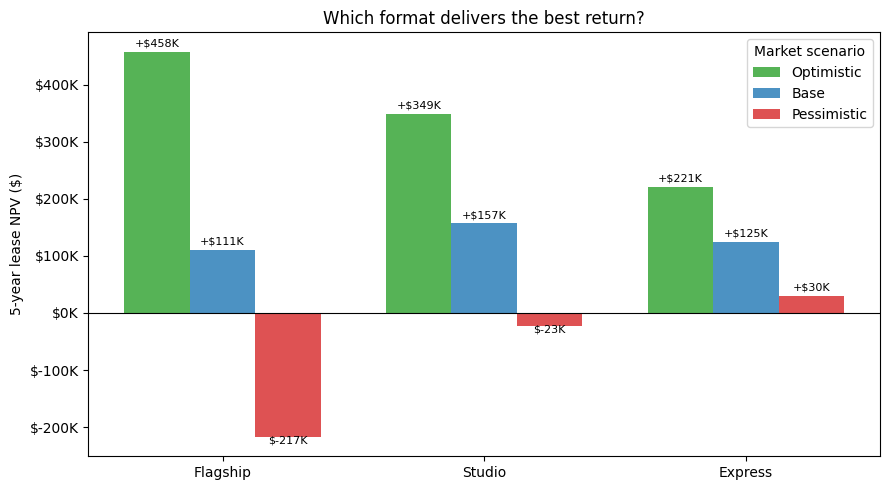

In [2]:
SCENARIO_COLORS = {"Optimistic": "#2ca02c", "Base": "#1f77b4", "Pessimistic": "#d62728"}
fmt_names = list(FORMATS.keys())
x = np.arange(len(fmt_names))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (scenario, color) in enumerate(SCENARIO_COLORS.items()):
    params = SCENARIOS.get(scenario, {})
    npvs = []
    for fmt, base in FORMATS.items():
        if fmt == "Studio":
            npvs.append(studio_npv(**params))
        else:
            ratio = params.get("daily_visits", base["daily_visits"]) / STUDIO["daily_visits"]
            buildout_ratio = params.get("buildout", STUDIO["buildout"]) / STUDIO["buildout"]
            adj = {**base,
                   "daily_visits": int(base["daily_visits"] * ratio),
                   "fee_growth": params.get("fee_growth", FEE_GROWTH),
                   "buildout": base["buildout"] * buildout_ratio}
            npvs.append(studio_npv(**adj))
    bars = ax.bar(x + (i - 1) * bar_w, npvs, bar_w,
                  label=scenario, color=color, alpha=0.8)
    for bar, val in zip(bars, npvs):
        sign = "+" if val >= 0 else ""
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (5_000 if val >= 0 else -15_000),
                f"{sign}${val/1e3:.0f}K",
                ha="center", va="bottom", fontsize=8)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(fmt_names, fontsize=10)
ax.set_ylabel("5-year lease NPV ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Which format delivers the best return?")
ax.legend(title="Market scenario")
plt.tight_layout()
plt.show()

**What this chart answers:** "Under any scenario, which format should we open?"
Studio wins the base case and stays positive in the optimistic scenario.
Flagship's $460K buildout suppresses its NPV despite higher revenue —
it only approaches Studio if the market turns out strongly optimistic.
All formats go negative under Pessimistic, which means the real question is
confidence in the daily visit assumption.

## Chart 2 — "What should we worry about most?"

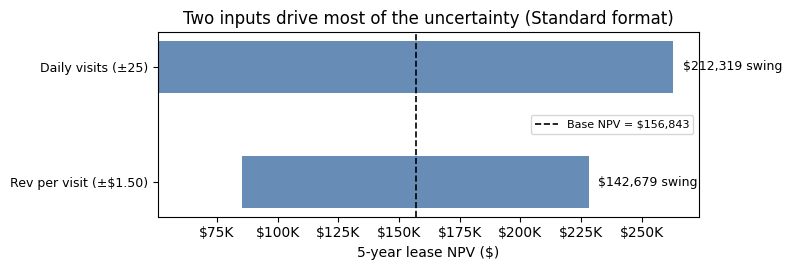

In [3]:
top2 = tornado.tail(2).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 2.8))
y = np.arange(len(top2))
for i, row in top2.iterrows():
    lo, hi = sorted([row["low_npv"], row["high_npv"]])
    ax.barh(i, hi - lo, left=lo, height=0.45, color="#4C78A8", alpha=0.85)
    ax.text(hi + 4_000, i, f"${row['range_npv']:,.0f} swing", va="center", fontsize=9)

ax.axvline(CENTRAL_NPV, color="black", ls="--", lw=1.2,
           label=f"Base NPV = ${CENTRAL_NPV:,.0f}")
ax.set_yticks(y)
ax.set_yticklabels(top2["driver"], fontsize=9)
ax.set_xlabel("5-year lease NPV ($)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Two inputs drive most of the uncertainty (Standard format)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What this chart answers:** "If our assumptions are off, which one matters most?"
Daily visit count dominates — a swing of just ±25 visits per day moves
NPV by more than any other factor combined. Get firm foot-traffic counts from
pedestrian data or nearby comparable studios before signing the lease. Revenue
per visit is second but considerably smaller in impact.

## Chart 3 — "How many members do we need through the door each day?"

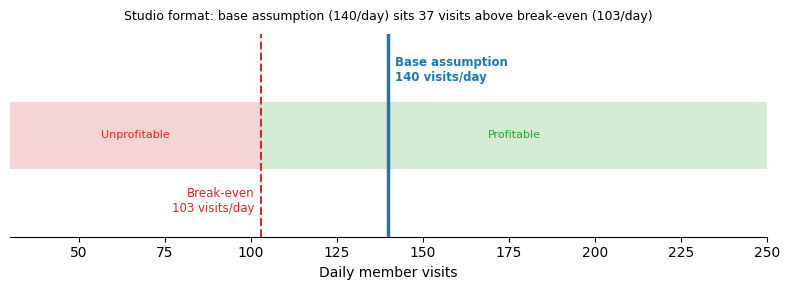

In [4]:
lo_chart, hi_chart = 30, 250

fig, ax = plt.subplots(figsize=(8, 3.0))
ax.barh(0, breakeven_visits - lo_chart, left=lo_chart,
        height=0.5, color="#d62728", alpha=0.20)
ax.barh(0, hi_chart - breakeven_visits, left=breakeven_visits,
        height=0.5, color="#2ca02c", alpha=0.20)
ax.text((lo_chart + breakeven_visits) / 2, 0, "Unprofitable",
        ha="center", va="center", fontsize=8, color="#d62728")
ax.text((breakeven_visits + hi_chart) / 2, 0, "Profitable",
        ha="center", va="center", fontsize=8, color="#2ca02c")

ax.axvline(breakeven_visits, color="#d62728", lw=1.5, ls="--", zorder=5)
ax.text(breakeven_visits - 2, -0.38,
        f"Break-even\n{breakeven_visits:.0f} visits/day",
        ha="right", va="top", color="#d62728", fontsize=8.5)

ax.axvline(STUDIO["daily_visits"], color="#1f77b4", lw=2.5, zorder=6)
ax.text(STUDIO["daily_visits"] + 2, 0.38,
        f"Base assumption\n{STUDIO['daily_visits']} visits/day",
        ha="left", va="bottom", color="#1f77b4", fontsize=8.5, fontweight="bold")

ax.set_xlim(lo_chart, hi_chart)
ax.set_ylim(-0.75, 0.75)
ax.set_yticks([])
ax.set_xlabel("Daily member visits")
ax.set_title(
    f"Studio format: base assumption ({STUDIO['daily_visits']}/day) "
    f"sits {cushion:.0f} visits above break-even ({breakeven_visits:.0f}/day)",
    fontsize=9, pad=10
)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**What this chart answers:** "At what point does the recommendation break down?"
The Studio format needs roughly 103 member visits per day to recover its buildout cost.
The base assumption of 140 gives a cushion of about 37 visits — meaningful, but
since daily visit count is also the dominant tornado driver, validating the
foot-traffic estimate before signing is the single most important pre-commitment step.

---
## The memo

## Apex Athletic Co. — New Market Entry Format Analysis

**Recommendation:** Open the **Studio (2,200 sq ft) format** in the new market.
It delivers the highest 5-year lease NPV in the base case (+$157K) while keeping
buildout cost at $195K — less than half the Flagship's exposure.

**Key numbers:**
- Studio base-case NPV: **+$157K** | Optimistic: **+$349K** | Pessimistic: **−$23K**
- Break-even: **103 visits/day** vs. base assumption of **140/day** (37-visit cushion)
- Flagship base-case NPV: +$111K — similar buildout risk for far less return

**Biggest risk:** Daily visit count. A drop of 37 visits per day — from 140 to
103 — eliminates the entire return. This is not an extreme scenario; the Pessimistic
case (105/day) sits just above that threshold.

**What would change this recommendation:** If location scouting surfaces a site with
confirmed foot traffic above ~175 visits/day, Flagship becomes competitive and
worth re-evaluating. If visit estimates for the Studio site cannot be
validated above 110/day, defer and re-scout rather than open at a loss.